# tast 3

task for data structures, functions, and scripting Pandas for data 
manipulation : reading CSV, filtering, merging to data visualization: 
Matplotlib & Seaborn basics Assignments

In [2]:
import pandas as pd

df = pd.read_csv('data.csv')

print("--- FIRST 5 WORKOUT RECORDS ---")
print(df.head())

print("\n--- DATASET DETAILS ---")
df.info()

--- FIRST 5 WORKOUT RECORDS ---
   Duration          Date  Pulse  Maxpulse  Calories
0        60  '2020/12/01'    110       130     409.1
1        60  '2020/12/02'    117       145     479.0
2        60  '2020/12/03'    103       135     340.0
3        45  '2020/12/04'    109       175     282.4
4        45  '2020/12/05'    117       148     406.0

--- DATASET DETAILS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Duration  32 non-null     int64  
 1   Date      31 non-null     object 
 2   Pulse     32 non-null     int64  
 3   Maxpulse  32 non-null     int64  
 4   Calories  30 non-null     float64
dtypes: float64(1), int64(3), object(1)
memory usage: 1.4+ KB


In [3]:
df['Calories'] = df['Calories'].fillna(df['Calories'].median())

intense_workouts = df[(df['Duration'] >= 60) & (df['Calories'] > 350)]

print("--- HIGH-INTENSITY WORKOUT SESSIONS (>= 60 mins & > 350 Calories) ---")
print(intense_workouts[['Date', 'Duration', 'Pulse', 'Calories']])

--- HIGH-INTENSITY WORKOUT SESSIONS (>= 60 mins & > 350 Calories) ---
            Date  Duration  Pulse  Calories
0   '2020/12/01'        60    110     409.1
1   '2020/12/02'        60    117     479.0
6   '2020/12/07'        60    110     374.0
14  '2020/12/14'        60    104     379.3
21  '2020/12/21'        60    108     364.2
30  '2020/12/30'        60    102     380.3


In [4]:
def classify_heart_rate(pulse):
    if pulse >= 110:
        return "High Intensity Aerobic"
    else:
        return "Moderate Fat Burn"

df['Workout_Zone'] = df['Pulse'].apply(classify_heart_rate)

print("--- RE-CLASSIFIED WORKOUT DATA ---")
print(df[['Pulse', 'Maxpulse', 'Workout_Zone']].head())

--- RE-CLASSIFIED WORKOUT DATA ---
   Pulse  Maxpulse            Workout_Zone
0    110       130  High Intensity Aerobic
1    117       145  High Intensity Aerobic
2    103       135       Moderate Fat Burn
3    109       175       Moderate Fat Burn
4    117       148  High Intensity Aerobic


In [5]:
zone_info = pd.DataFrame({
    'Workout_Zone': ['High Intensity Aerobic', 'Moderate Fat Burn'],
    'Target_Effort': ['80%-90% Effort', '60%-70% Effort']
})

merged_df = pd.merge(df, zone_info, on='Workout_Zone', how='left')

print("\n--- FINAL MERGED DATASET WITH EFFORT LOOKUPS ---")
print(merged_df[['Date', 'Pulse', 'Workout_Zone', 'Target_Effort']].head())


--- FINAL MERGED DATASET WITH EFFORT LOOKUPS ---
           Date  Pulse            Workout_Zone   Target_Effort
0  '2020/12/01'    110  High Intensity Aerobic  80%-90% Effort
1  '2020/12/02'    117  High Intensity Aerobic  80%-90% Effort
2  '2020/12/03'    103       Moderate Fat Burn  60%-70% Effort
3  '2020/12/04'    109       Moderate Fat Burn  60%-70% Effort
4  '2020/12/05'    117  High Intensity Aerobic  80%-90% Effort


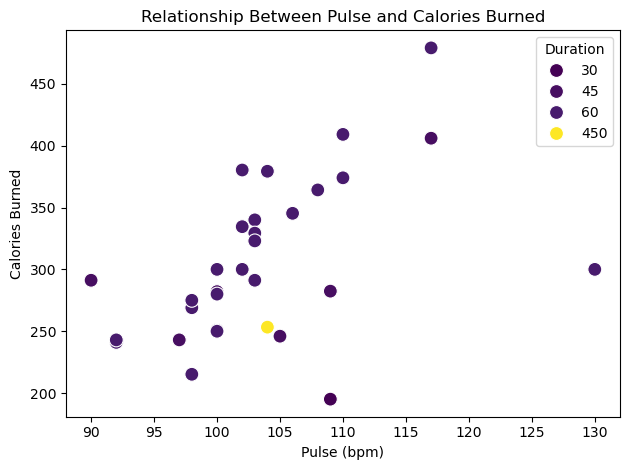

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.clf()

sns.scatterplot(data=df, x='Pulse', y='Calories', hue='Duration', palette='viridis', s=100)

plt.title('Relationship Between Pulse and Calories Burned')
plt.xlabel('Pulse (bpm)')
plt.ylabel('Calories Burned')
plt.tight_layout()

plt.savefig('pulse_vs_calories.png')

C:\Users\HP\AppData\Local\Temp\ipykernel_23608\1232814370.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=duration_counts.index, y=duration_counts.values, palette='Blues_d')


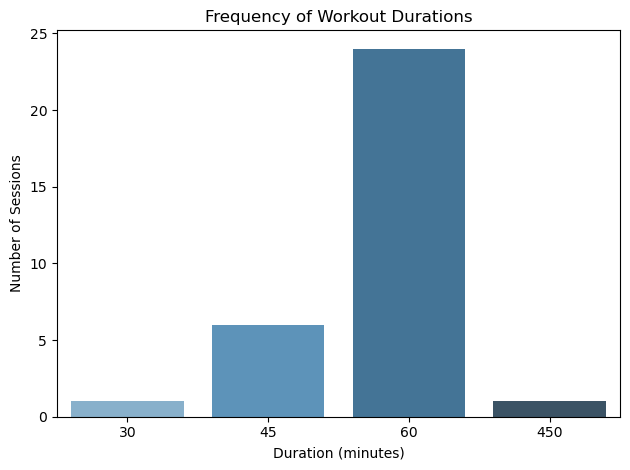

In [7]:
plt.clf()

duration_counts = df['Duration'].value_counts().sort_index()

sns.barplot(x=duration_counts.index, y=duration_counts.values, palette='Blues_d')

plt.title('Frequency of Workout Durations')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Sessions')
plt.tight_layout()

plt.savefig('workout_durations.png')